In [2]:
# import all necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.utils.validation import check_is_fitted

## Prepare Data

### Import

In [23]:
# function "wrangle" takes a file, prepares the file and returns a dataframe
def wrangle(filepath):
    df = pd.read_csv(filepath)
    # use masking to create a subset of the data and filter out unnecessary data. For this, we are looking at apartments in capital
    #federal under 400000 usd
    mask_city = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_property_type = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400000

    # combine all subsets
    df = df[mask_city & mask_property_type & mask_price]

    # using a quantile to remove observations considered as outliers in the "surface_covered_in_m2."
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df=df[mask_area]
    return df

In [24]:
# using the wrangle function to create a dataframe
df = wrangle("data/buenos-aires-real-estate-1.csv")
print("df shape:", df.shape)
df.head()

df shape: (1343, 16)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...


### Explore

Text(0.5, 1.0, 'Distribution of Apartment')

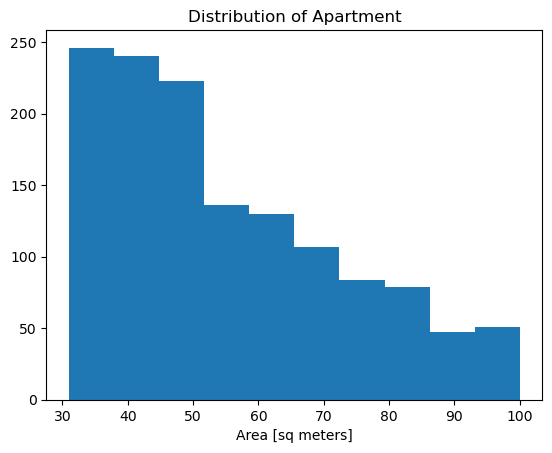

In [25]:
# create a hist that shows the distribution of apartment size by area in square meters
plt.hist(df["surface_covered_in_m2"])
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Apartment")

In [26]:
# calculate the summary of statistics using the describe method
df.describe()["surface_covered_in_m2"]

count    1343.000000
mean       55.076694
std        18.160427
min        31.000000
25%        40.000000
50%        50.000000
75%        68.500000
max       100.000000
Name: surface_covered_in_m2, dtype: float64

Text(0.5, 1.0, 'Buenos Aires: Price vs. Area')

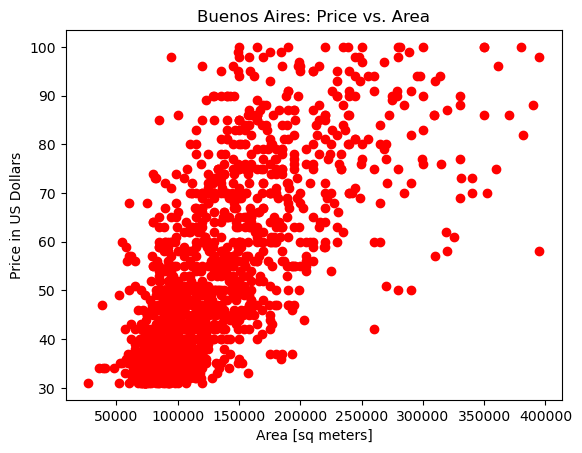

In [28]:
# use scatter plot showing price ("price_aprox_usd") vs area ("surface_covered_in_m2")
plt.scatter(df["price_aprox_usd"], df["surface_covered_in_m2"], color = "r")
plt.xlabel("Area [sq meters]")
plt.ylabel("Price in US Dollars")
plt.title("Buenos Aires: Price vs. Area")


### Split

In [30]:
# create feature data split. This is the information that will be used to make the predictions
features = ["surface_covered_in_m2"]
X_train = df[features]
X_train

,surface_covered_in_m2
4,70.0
9,42.0
29,54.0
40,42.0
41,50.0
...,...
8589,42.0
8590,41.0
8593,43.0
8601,70.0


In [31]:
# create the target data split. this is what I want to predict
target = "price_aprox_usd"
y_train = df[target]
y_train

4       129000.00
9        87000.00
29      118000.00
40       57000.00
41       90000.00
          ...    
8589     73536.95
8590    119000.00
8593     62000.00
8601    125000.00
8604     78000.00
Name: price_aprox_usd, Length: 1343, dtype: float64

## Build Model

### Baseline

In [32]:
# build a baseline model that predicts the price of an apartment regardless of the size
y_mean = y_train.mean()
y_mean

np.float64(135527.83871928515)

In [34]:
# create an array of repeated baseline model values of the same length as y_train
y_pred_baseline = [y_mean] * len(y_train)
y_pred_baseline[:5]

[np.float64(135527.83871928515),
 np.float64(135527.83871928515),
 np.float64(135527.83871928515),
 np.float64(135527.83871928515),
 np.float64(135527.83871928515)]

In [ ]:
# add line to plot showing the relationship between the baseline model and our features
plt.plot(X_train, y_pred_baseline, color="magenta", label="Baseline Model")

plt.scatter(X_train, y_train)
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs. Area")
plt.legend();

# from the plot, we can see that regardless of the area, the model returns the same price

In [37]:
# calculate the mean absolute error which is the average difference between the prediction and the actual price
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean apt price", round(y_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean apt price 135527.84
Baseline MAE: 45199.46


### Iterate

In [38]:
# create model
model = LinearRegression()

In [39]:
# fit the feature and target into the model
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Evaluate

In [40]:
# use the model to predict the prices of apartments
y_pred_training = model.predict(X_train)
y_pred_training[:5]

array([169151.87330223, 106064.44707446, 133101.91545779, 106064.44707446,
       124089.42599668])

In [41]:
# calculate the mean absolute error of the predicted values
mae_training = mean_absolute_error(y_pred_training, y_train)
print("Training MAE:", round(mae_training, 2))

Training MAE: 31248.26


In [42]:
# import test data and use the model to predict 
X_test = pd.read_csv("data/buenos-aires-test-features.csv")[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

0    117330.058901
1    135355.037823
2     88039.468152
3     88039.468152
4    106064.447074
dtype: float64

In [43]:
# calculate the intercept
intercept = round(model.intercept_, 2)
print("Model Intercept:", intercept)

Model Intercept: 11433.31


In [45]:
# extract the coefficient
coefficient = round(model.coef_[0], 2)
print('Model coefficient for "surface_covered_in_m2":', coefficient)

Model coefficient for "surface_covered_in_m2": 2253.12


In [46]:
# print the equation
print(f"apartment_price = {intercept} + {coefficient} * surface_covered") 

apartment_price = 11433.31 + 2253.12 * surface_covered


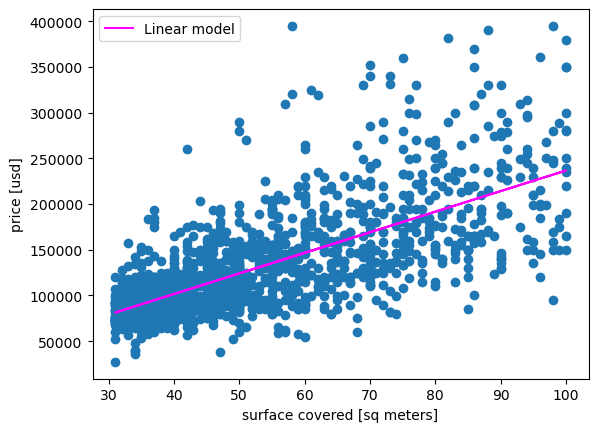

In [48]:
# Add a line to the plot
plt.plot(X_train.values, model.predict(X_train), color='magenta', label='Linear model')

plt.scatter(X_train, y_train)
plt.xlabel("surface covered [sq meters]")
plt.ylabel("price [usd]")
plt.legend();